In [ ]:
%pip install imagehash

In [13]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, color, util, filters, restoration, morphology
from sklearn.decomposition import PCA
import imagehash
from PIL import Image
import matplotlib.image as mpimg
from skimage.util import random_noise
from sklearn.cluster import KMeans


# Helper to show images
def show(img, title="Image", cmap=None):
    plt.figure(figsize=(4,4))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

## Exercise 1: Image Selection and Reading
	•	Choose an image file of your choice (e.g., .jpg, .png, .bmp).
	•	Upload the image.
	•	Write a program to read and display the image.

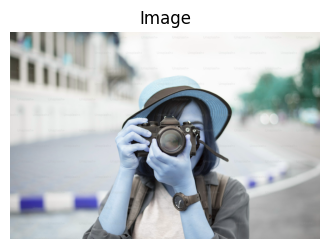

In [5]:
img = cv2.imread('/content/img.jpeg')
show(img)

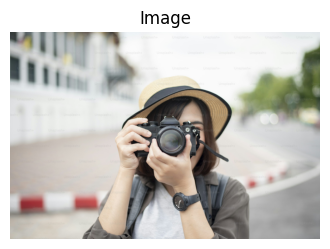

In [7]:
img = mpimg.imread('/content/img.jpeg')
show(img)

In [18]:
img = cv2.imread('/content/img.jpeg', cv2.IMREAD_GRAYSCALE)

## Exercise 2:: Image Compression using PCA
	•	Convert the chosen image (from Exercise 1) into grayscale.
	•	Apply Principal Component Analysis (PCA) to reduce its dimensionality.
    •   Try different values of n_components (e.g., 10, 30, 50, 100).
	•	Compare the original and compressed images visually.


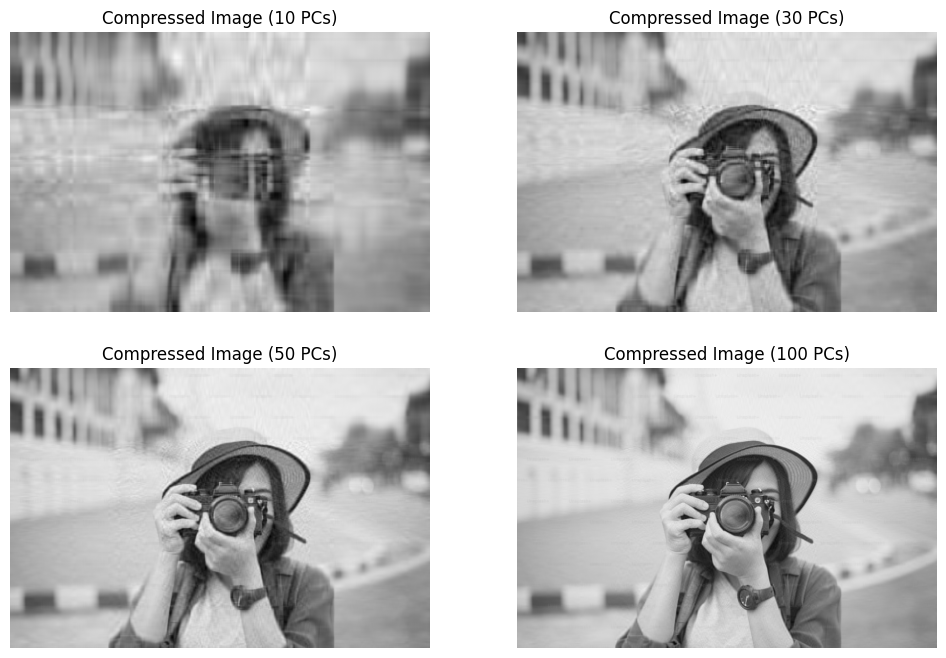

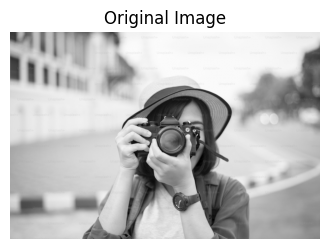

In [10]:
img_normalized = img / 255.0

components_list = [10, 30, 50, 100]

plt.figure(figsize=(12, 8))

for i, n in enumerate(components_list, 1):
    pca = PCA(n_components=n)
    compressed = pca.fit_transform(img_normalized)

    reconstructed = pca.inverse_transform(compressed)

    plt.subplot(2, 2, i)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"Compressed Image ({n} PCs)")
    plt.axis('off')

plt.figure(figsize=(4,4))
plt.imshow(img_normalized, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

## Exercise 3: Image Restoration (Denoising)
	•	Add noise (e.g., Gaussian noise, salt-and-pepper noise) to your chosen image.
	•	Apply different denoising techniques to restore the image.
	•	Compare the results visually.

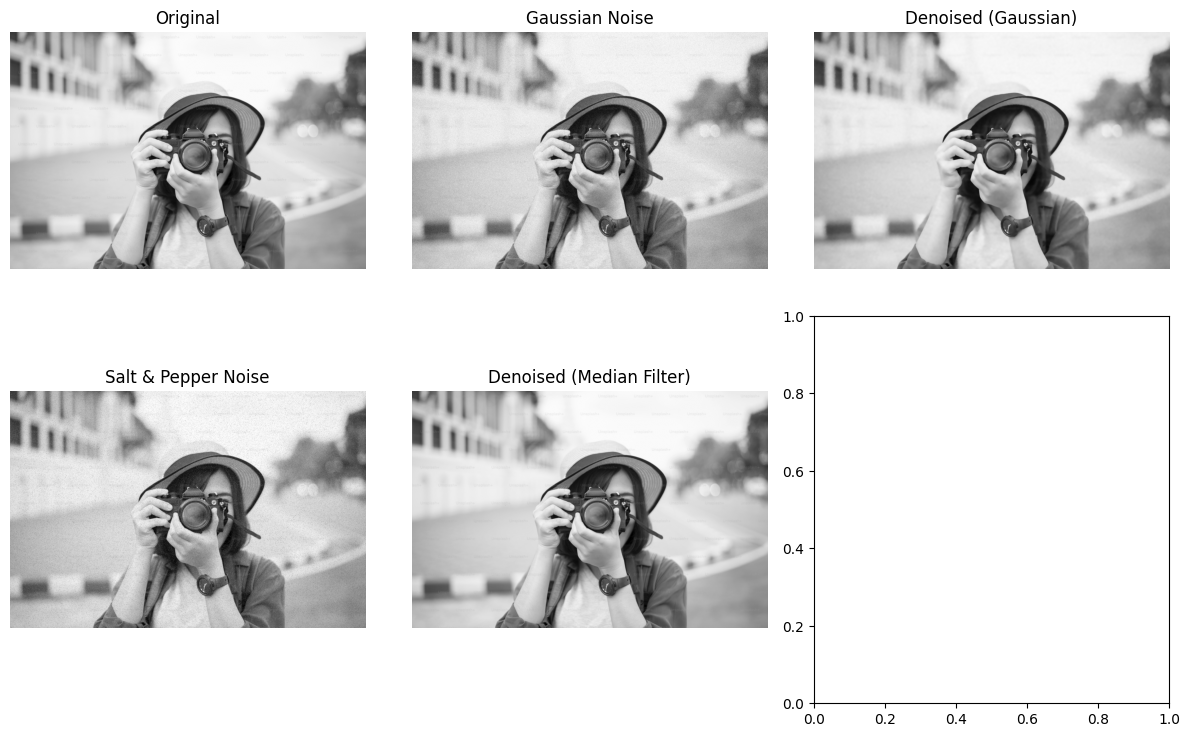

In [12]:
noisy_gauss = random_noise(img, mode='gaussian')

noisy_sp = random_noise(img, mode='s&p')

denoised_gauss = cv2.fastNlMeansDenoising((noisy_gauss*255).astype(np.uint8), None, 30, 7, 21)
denoised_sp = cv2.medianBlur((noisy_sp*255).astype(np.uint8), 3)

fig, axes = plt.subplots(2,3, figsize=(12,8))
axes = axes.ravel()

axes[0].imshow(img, cmap='gray'); axes[0].set_title("Original"); axes[0].axis('off')
axes[1].imshow(noisy_gauss, cmap='gray'); axes[1].set_title("Gaussian Noise"); axes[1].axis('off')
axes[2].imshow(denoised_gauss, cmap='gray'); axes[2].set_title("Denoised (Gaussian)"); axes[2].axis('off')
axes[3].imshow(noisy_sp, cmap='gray'); axes[3].set_title("Salt & Pepper Noise"); axes[3].axis('off')
axes[4].imshow(denoised_sp, cmap='gray'); axes[4].set_title("Denoised (Median Filter)"); axes[4].axis('off')

plt.tight_layout()
plt.show()

## Exercise 4: Image Segmentation

	•	Segmentation is the process of partitioning an image into meaningful regions such as objects or boundaries.
	•	Perform threshold-based segmentation (e.g., global thresholding, Otsu’s method).
	•	Compare the results visually.

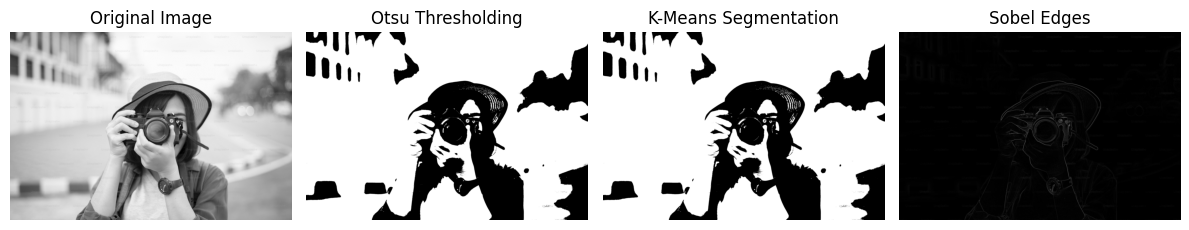

In [21]:
_, otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)


pixel_vals = img.reshape((-1,1))
pixel_vals = np.float32(pixel_vals)

k = 2  # number of clusters
kmeans = KMeans(n_clusters=k, random_state=42).fit(pixel_vals)
segmented = kmeans.cluster_centers_[kmeans.labels_]
segmented_img = segmented.reshape(img.shape).astype(np.uint8)
edges = filters.sobel(img)

plt.figure(figsize=(12,5))

plt.subplot(1,4,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(otsu, cmap='gray')
plt.title("Otsu Thresholding")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(segmented_img, cmap='gray')
plt.title("K-Means Segmentation")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(edges, cmap='gray')
plt.title("Sobel Edges")
plt.axis('off')

plt.tight_layout()
plt.show()

## Exercise 5: Image Fingerprint Generation (Perceptual Hashing)

	•	Generate image fingerprints using perceptual hashing methods (e.g., Average Hash, Difference Hash, or pHash).
	•	Compare hash values of original and modified images.

In [16]:
from PIL import Image

img = Image.open("/content/img.jpeg")

ahash = imagehash.average_hash(img)
phash = imagehash.phash(img)
dhash = imagehash.dhash(img)

print("Average Hash:", ahash)
print("Perceptual Hash:", phash)
print("Difference Hash:", dhash)

img_resized = img.resize((256,256))
print("pHash difference (original vs resized):", phash - imagehash.phash(img_resized))

Average Hash: 3f5ee4e2e3e36058
Perceptual Hash: e59699a5a867720e
Difference Hash: f2f48ccec6c6c292
pHash difference (original vs resized): 0


## Exercise 6. Image Quality Detection (Blurriness)
	1.	Implement blurriness detection using Laplacian variance.
	2.	Test the method on different images (sharp vs blurred).
	3.	Experiment with different thresholds — what value works best?

In [24]:
def detect_blur(img, threshold=100):

    # Compute Laplacian variance
    lap_var = cv2.Laplacian(img, cv2.CV_64F).var()

    if lap_var < threshold:
        print(f"Image is Blurry (Laplacian Variance = {lap_var:.2f})")
    else:
        print(f"Image is Sharp (Laplacian Variance = {lap_var:.2f})")

# Test on an image
detect_blur(img)

Image is Blurry (Laplacian Variance = 32.91)


## Exercise 7. Image Quality Enhancement (Histogram Equalization)
	1.	Apply histogram equalization to an image with low contrast.
	2.	Plot and compare histograms of the original and equalized images.

/tmp/ipython-input-3515090590.py:11: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(), 256, [0,256])
/tmp/ipython-input-3515090590.py:21: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(equalized.ravel(), 256, [0,256])


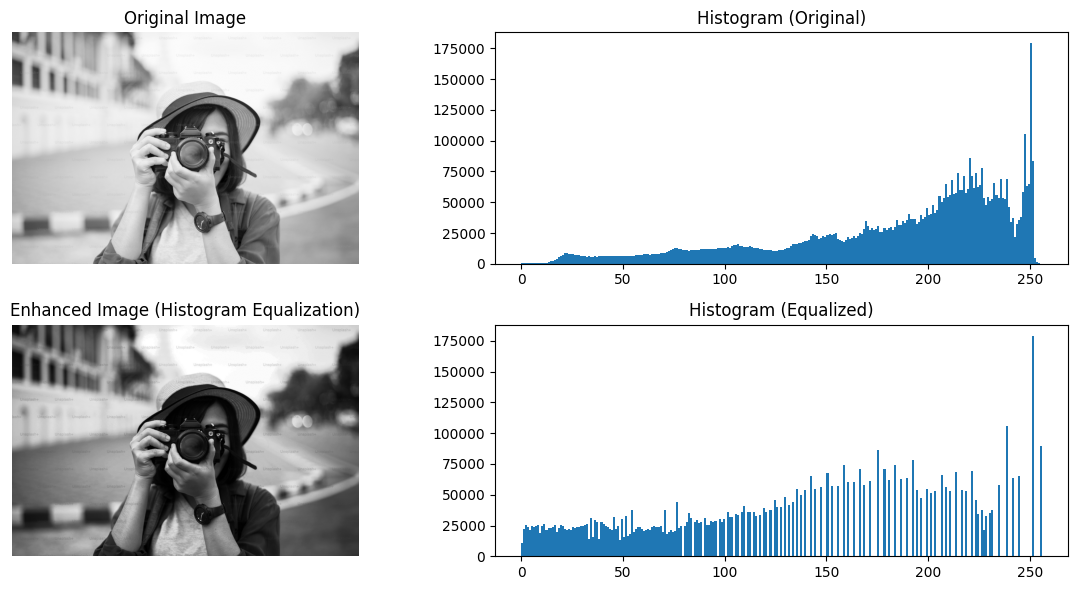

In [32]:
equalized = cv2.equalizeHist(img)

plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2,2,2)
plt.hist(img.ravel(), 256, [0,256])
plt.title("Histogram (Original)")

# Enhanced image and histogram
plt.subplot(2,2,3)
plt.imshow(equalized, cmap='gray')
plt.title("Enhanced Image (Histogram Equalization)")
plt.axis('off')

plt.subplot(2,2,4)
plt.hist(equalized.ravel(), 256, [0,256])
plt.title("Histogram (Equalized)")

plt.tight_layout()
plt.show();